In [31]:
import pandas as pd

df = pd.read_csv(r"\Users\vedur\OneDrive\Desktop\Customer Segmentation Project\Mall_Customers.csv")

print(df.head())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0


In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
None


In [33]:
print(df.isnull().sum())

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64


In [34]:

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                59.9                    58.0
1                48.4                    37.0
2                70.5                    26.0
3                81.1                    30.0
4                42.1                    58.0


In [15]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [16]:
%matplotlib inline

In [38]:

X = X.dropna()

print(X.isnull().sum())

Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

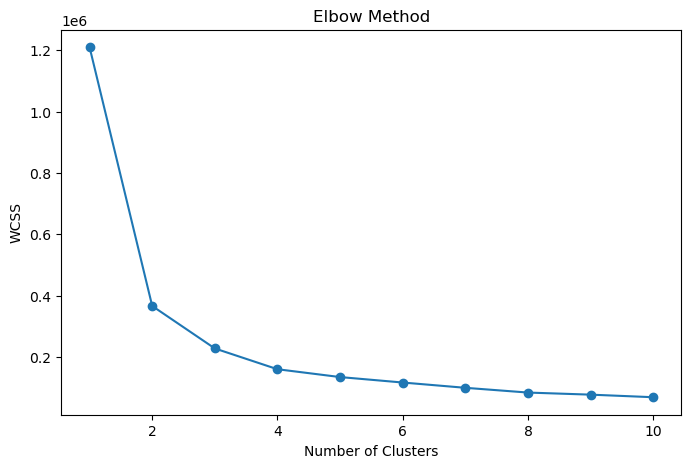

In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [40]:
kmeans = KMeans(n_clusters=5, random_state=42)

X['Cluster'] = kmeans.fit_predict(X)

print(X.head())

   Annual Income (k$)  Spending Score (1-100)  Cluster
0                59.9                    58.0        1
1                48.4                    37.0        1
2                70.5                    26.0        0
3                81.1                    30.0        2
4                42.1                    58.0        1


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\vedur\AppData\Local\Temp\ipykernel_7260\444457141.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Cluster'] = kmeans.fit_predict(X)


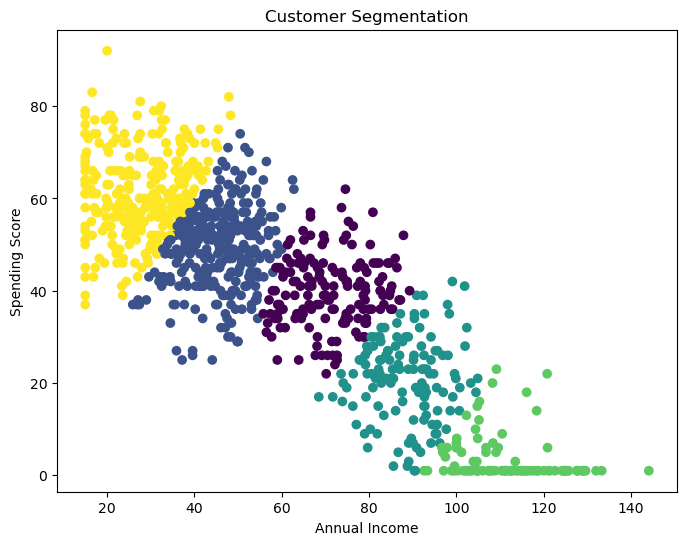

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=X['Cluster']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [43]:
df = df.loc[X.index]

df['Cluster'] = X['Cluster']

print(df.head())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0        1000      M  39.0                59.9                    58.0   
1        1001      M  34.0                48.4                    37.0   
2        1002      F  40.0                70.5                    26.0   
3        1003      F  47.0                81.1                    30.0   
4        1004      F  33.0                42.1                    58.0   

   Cluster  
0        1  
1        1  
2        0  
3        2  
4        1  


In [44]:
df.to_csv("customer_segments.csv", index=False)

print("File saved successfully")

File saved successfully


In [45]:
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 71.198765               39.851852
1                 45.510256               49.278846
2                 88.520149               21.000000
3                112.005000                3.480000
4                 27.920922               61.131206


In [46]:
df = df.loc[X.index]

df['Cluster'] = X['Cluster']

print(df.head())

   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)  \
0        1000      M  39.0                59.9                    58.0   
1        1001      M  34.0                48.4                    37.0   
2        1002      F  40.0                70.5                    26.0   
3        1003      F  47.0                81.1                    30.0   
4        1004      F  33.0                42.1                    58.0   

   Cluster  
0        1  
1        1  
2        0  
3        2  
4        1  


In [47]:
df.to_csv("Mall_Customers.csv", index=False)

print("CSV updated successfully")

CSV updated successfully


In [48]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster'],
      dtype='object')


In [49]:
df.to_csv("customer_segments.csv", index=False)

print("New file saved")

New file saved


In [50]:
import os
print(os.getcwd())

C:\Users\vedur
